In [1]:
import requests                         # for HTTP requests to fetch data from IRSA API
import pandas as pd                     # for handling tabular data
from astropy.coordinates import SkyCoord  # for converting RA/Dec into degrees
import astropy.units as u               # for specifying units
from io import StringIO                 # to treat text response as a file (for pandas)


# Function to query ZTF (Zwicky Transient Facility) lightcurves

def get_ztf_lightcurve(ra_deg, dec_deg, radius_arcsec=1.2, band="r", fmt="csv"):
    """
    Query the ZTF IRSA API for lightcurves around a given RA, Dec position.

    Parameters:
        ra_deg (float)  → Right Ascension in degrees
        dec_deg (float) → Declination in degrees
        radius_arcsec   → Search radius around target (arcseconds)
        band (str)      → Photometric band to fetch ('g', 'r', 'i')
        fmt (str)       → Response format (default: CSV)
    """
    base_url = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"
    
    # Convert radius from arcsec → degrees
    radius_deg = radius_arcsec / 3600.0
    
    # API query parameters
    params = {
        "POS": f"CIRCLE {ra_deg} {dec_deg} {radius_deg}",
        "BANDNAME": band,
        "FORMAT": fmt.lower()
    }
    
    # Fetch data
    response = requests.get(base_url, params=params)
    response.raise_for_status()
    
    # Return as pandas DataFrame
    return pd.read_csv(StringIO(response.text), comment="#")


#Load catalogue of objects

catalogue = pd.read_csv("magnetic_cataclysmic_variables.txt")
# catalogue has columns  "Name", "RA(J2000)", "DEC(J2000)"

all_lightcurves = []   # container for results


#Loop through catalogue and fetch lightcurves

for _, row in catalogue.iterrows():   # limit to first 5 for testing
    name = row["Name"]
    ra_str, dec_str = row["RA(J2000)"], row["DEC(J2000)"]
    
    try:
        # Convert RA/Dec to decimal degrees
        coord = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg))
        ra_deg, dec_deg = coord.ra.deg, coord.dec.deg
        
        print(f"Querying ZTF for {name} at RA={ra_deg:.4f}, Dec={dec_deg:.4f}")
        
        # Get r-band lightcurve
        df = get_ztf_lightcurve(ra_deg, dec_deg, radius_arcsec=1.2, band="r")
        
        if not df.empty:
            df["object"] = name
            all_lightcurves.append(df)
            print(f"   Got {len(df)} points for {name}")
        else:
            print(f"  No data returned for {name}")
    
    except Exception as e:
        print(f"   Failed for {name}: {e}")


# Save raw merged results

    merged = pd.concat(all_lightcurves, ignore_index=True)
    merged.to_csv("lightcurves_fetched_from_CV_catalogue.csv", index=False)
    
    print(f"\n Saved r-band lightcurves for {len(catalogue)} stars "
          f"({len(merged)} total points)")
    
    
    # Group by object into compact form (by oid)
    
    data = pd.read_csv("lightcurves_fetched_from_CV_catalogue.csv")
    grouped = data.groupby("object", sort=False, as_index=False).agg(list)
    
    # Convert lists to single-line strings (joined by ;)
    for col in grouped.columns:
        if col != "object":
            grouped[col] = grouped[col].apply(lambda x: ";".join(map(str, x)))
    
    grouped.to_csv("lightcurves_grouped_r_clean.csv", index=False)
    print(" Grouped output saved to 'lightcurves_grouped_r_clean.csv'")
    
else:
    print("\n No lightcurves fetched.")

Querying ZTF for V479 And at RA=4.7371, Dec=34.9122
   Got 2285 points for V479 And

 Saved r-band lightcurves for 245 stars (2285 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for V1309 Ori at RA=78.9225, Dec=1.0778
   Got 956 points for V1309 Ori

 Saved r-band lightcurves for 245 stars (3241 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for AI Tri at RA=30.9525, Dec=29.9906
   Got 1122 points for AI Tri

 Saved r-band lightcurves for 245 stars (4363 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for J0649-0737 at RA=102.4617, Dec=-7.6281
  No data returned for J0649-0737

 Saved r-band lightcurves for 245 stars (4363 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for MQ Dra at RA=238.3796, Dec=55.2708
   Got 1503 points for MQ Dra

 Saved r-band lightcurves for 245 stars (5866 total points)
 Grouped output saved to 'lightcurves


 Saved r-band lightcurves for 245 stars (38658 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for V2467 Cyg at RA=307.0521, Dec=41.8100
   Failed for V2467 Cyg: HTTPSConnectionPool(host='irsa.ipac.caltech.edu', port=443): Max retries exceeded with url: /cgi-bin/ZTF/nph_light_curves?POS=CIRCLE+307.05208333333326+41.809999999999995+0.0003333333333333333&BANDNAME=r&FORMAT=csv (Caused by NameResolutionError("HTTPSConnection(host='irsa.ipac.caltech.edu', port=443): Failed to resolve 'irsa.ipac.caltech.edu' ([Errno 11001] getaddrinfo failed)"))

 Saved r-band lightcurves for 245 stars (38658 total points)
 Grouped output saved to 'lightcurves_grouped_r_clean.csv'
Querying ZTF for J1654-1916 at RA=253.6821, Dec=-19.2753
   Failed for J1654-1916: HTTPSConnectionPool(host='irsa.ipac.caltech.edu', port=443): Max retries exceeded with url: /cgi-bin/ZTF/nph_light_curves?POS=CIRCLE+253.68208333333328+-19.275277777777777+0.0003333333333333333&BANDNAME=r&FORMAT

In [2]:
# we had a csv file containing more negative files. From them, we are extracting just 1500 elements(As we had 140 CVs, we took 10x negative data for better resolution of comparison) 
# Import required Python libraries

import requests              # used here to talk to the ZTF API
import pandas as pd          # Pandas for handling tabular data (reading/writing CSVs, merging, etc.)
from astropy.coordinates import SkyCoord   # Astropy helper to convert RA/Dec strings to decimal degrees
import astropy.units as u    # Unit system from Astropy (e.g., hours → degrees)
from io import StringIO      # Lets us treat raw text as if it were a file (for reading CSV from API response )

# Function to query ZTF (Zwicky Transient Facility) lightcurves

def get_ztf_lightcurve(ra_deg, dec_deg, radius_arcsec=1.2, band="r", fmt="csv"):
    """
    Query the ZTF IRSA API for lightcurves around a given RA, Dec position.

    Parameters:
        ra_deg (float): Right Ascension in degrees
        dec_deg (float): Declination in degrees
        radius_arcsec (float): Search radius around target (arcseconds)
        band (str): Photometric band to fetch ('g', 'r', 'i')
        fmt (str): Response format (default: CSV)
    """
    base_url = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"
    radius_deg = radius_arcsec / 3600.0  # convert arcsec → degrees

    params = {
        "POS": f"CIRCLE {ra_deg} {dec_deg} {radius_deg}",
        "BANDNAME": band,
        "FORMAT": fmt.lower(),
    }

    # Fetch data
    response = requests.get(base_url, params=params, timeout=60) # Send request to IRSA ZTF API (wait ≤60s) and raise error if the response is not successful
    response.raise_for_status()

    # Return as pandas DataFrame
    return pd.read_csv(StringIO(response.text), comment="#") #stringIO used for fetching data from a csv and lightcurves of objects fetched by treating the objects as raw texts and from ZTF server,It was a long text,I was confused if the file is well decorated, so I treated if any comments are there, that must start with #)


#  Load catalogue of objects (.csv)

catalogue = pd.read_csv("negatives.csv")  # Columns: objectId, ra, dec
print(f" Loaded catalogue with {len(catalogue)} objects")

all_lightcurves = []  # container for all results, a black array to store my output


#  Loop through catalogue and fetch lightcurves

for i, row in catalogue.head(1500).iterrows(): #1500 elements at minimmum, I need to take 1400 but some lightcurves were blank
    object_id = str(row["objectId"])
    ra_deg = float(row["ra"])
    dec_deg = float(row["dec"])

    print(f"\n ({i+1}) Querying ZTF for {object_id} at RA={ra_deg:.4f}, Dec={dec_deg:.4f}")

    try:
        # Fetch r-band data
        df = get_ztf_lightcurve(ra_deg, dec_deg, radius_arcsec=1.2, band="r") 

        if not df.empty:
            df["object"] = object_id
            all_lightcurves.append(df)
            print(f"   Got {len(df)} points for {object_id}")
        else:
            print(f"   No data returned for {object_id}")

    except requests.exceptions.Timeout: # used it to minimise server delays
        print(f"   Timeout for {object_id} — skipping.")
        continue
    except Exception as e:
        print(f"   Failed for {object_id}: {e}")
        continue


# Step 3: Save raw merged results

if all_lightcurves:
    merged = pd.concat(all_lightcurves, ignore_index=True)
    merged.to_csv("negatives_lightcurves_raw_r.parquet", index=False)
    print(f"\n Saved raw lightcurves with {len(merged)} total photometric points.")

    
    # Group by object for compact, CSV-friendly format
   
    grouped = merged.groupby("object", sort=False, as_index=False).agg(list) #merged the group by object column in the order as it was fetched

    # Convert list columns → single-line strings separated by ;
    for col in grouped.columns:
        if col != "object":
            grouped[col] = grouped[col].apply(lambda x: ";".join(map(str, x)))

    grouped.to_csv("negatives_lightcurves_grouped_r_clean.parquet", index=False)
    print(" Grouped output saved to 'negatives_lightcurves_grouped_r_clean.parquet'")

else:
    print("\n No lightcurves were fetched from ZTF.")

 Loaded catalogue with 2878 objects

 (1) Querying ZTF for ZTF17aaatdnl at RA=92.5702, Dec=20.4072
   Got 1768 points for ZTF17aaatdnl

 (2) Querying ZTF for ZTF18aaawejy at RA=98.2217, Dec=15.4851
   Got 2376 points for ZTF18aaawejy

 (3) Querying ZTF for ZTF18aaphvtk at RA=92.9264, Dec=19.4704
   Got 1807 points for ZTF18aaphvtk

 (4) Querying ZTF for ZTF18aawadfc at RA=282.3956, Dec=15.1392
   Got 1955 points for ZTF18aawadfc

 (5) Querying ZTF for ZTF18aawccls at RA=291.6871, Dec=11.3786
   Got 1682 points for ZTF18aawccls

 (6) Querying ZTF for ZTF18aawkwln at RA=281.5963, Dec=13.8741
   Got 3078 points for ZTF18aawkwln

 (7) Querying ZTF for ZTF18aawsqdu at RA=288.5013, Dec=13.4138
   Got 3475 points for ZTF18aawsqdu

 (8) Querying ZTF for ZTF18aawvavc at RA=284.0627, Dec=14.0028
   Got 1965 points for ZTF18aawvavc

 (9) Querying ZTF for ZTF18aaxalgo at RA=288.3332, Dec=13.2284
   Got 3556 points for ZTF18aaxalgo

 (10) Querying ZTF for ZTF18aaxcytk at RA=293.5644, Dec=14.8676
  

In [261]:
#importing useful Python libraries
import pandas as pd
import light_curve as lc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from functools import reduce #for counting iterations
import joblib
import requests
import time
# Sklearn tools
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score, recall_score, f1_score
#from sklearn.model_selection import cross_val_score
# XGBoost
from xgboost import XGBClassifier


In [262]:
# Load the file with MCV lightcurve data
df = pd.read_csv("lightcurves_positives_r_band.csv")

print("DataFrame loaded with shape:", df.shape)
#print(df.head())

DataFrame loaded with shape: (140, 25)


In [263]:
# Define extractor with all features mentioned in this link 'https://github.com/light-curve/light-curve-python'
# definition of all extracted features is reported to my Overleaf file
extractor = lc.Extractor(
    lc.Mean(), #Mean magnitude
    lc.WeightedMean(),
    lc.StandardDeviation(),
    lc.Median(),
    lc.Amplitude(),
    lc.BeyondNStd(nstd=1),
    lc.Cusum(),
    lc.InterPercentileRange(0.10),
    lc.Kurtosis(),
    lc.LinearTrend(),
    lc.LinearFit(),   # slope, slope_sigma, reduced_chi2
    lc.MagnitudePercentageRatio(0.4, .05),
    lc.MagnitudePercentageRatio(0.2, 0.1),
    lc.MaximumSlope(),
    lc.MedianAbsoluteDeviation(),
    lc.MedianBufferRangePercentage(0.10),
    lc.PercentAmplitude(),
    lc.MeanVariance(),
    lc.AndersonDarlingNormal(),
    lc.ReducedChi2(),
    lc.Skew(),
    lc.StetsonK()
)

In [264]:
# Function to parse semicolon-separated arrays
def parse_array(x):
    return np.array([float(v) for v in str(x).split(";") if v != ""])
# Collect results
results = [] #empty array to store results
#Iterate through each row of the DataFrame (each row = one object)
for _, row in df.iterrows():
    try:
        t = parse_array(row["hjd"]) #time array for heleocentric julian date
        m = parse_array(row["mag"]) #magnitude column
        err = parse_array(row["magerr"]) #error
        feats = extractor(t, m, err, sorted=True, check=False)
        results.append([row["object"]] + list(feats))
    except Exception as e:
        print(f" Skipping {row['object']} due to error: {e}")

# Create DataFrame with proper headers
features_df_pos = pd.DataFrame(results, columns=["object"] + extractor.names)

# Save to CSV and Excel
features_df_pos.to_parquet("lightcurve_features_26.parquet", index=False)
print(" Feature extraction complete! Saved to:")
print("   - lightcurve_features_26.parquet")
#shape
print(features_df_pos.shape)

 Skipping PW Aqr due to error: time-series' length 3 is smaller than the minimum required length 4
 Feature extraction complete! Saved to:
   - lightcurve_features_26.parquet
(139, 27)


In [265]:
#correlation matrix for positive features
#correlation calculation
features_pos = features_df_pos.drop(columns=['object'])
corr_pos = features_pos.corr()

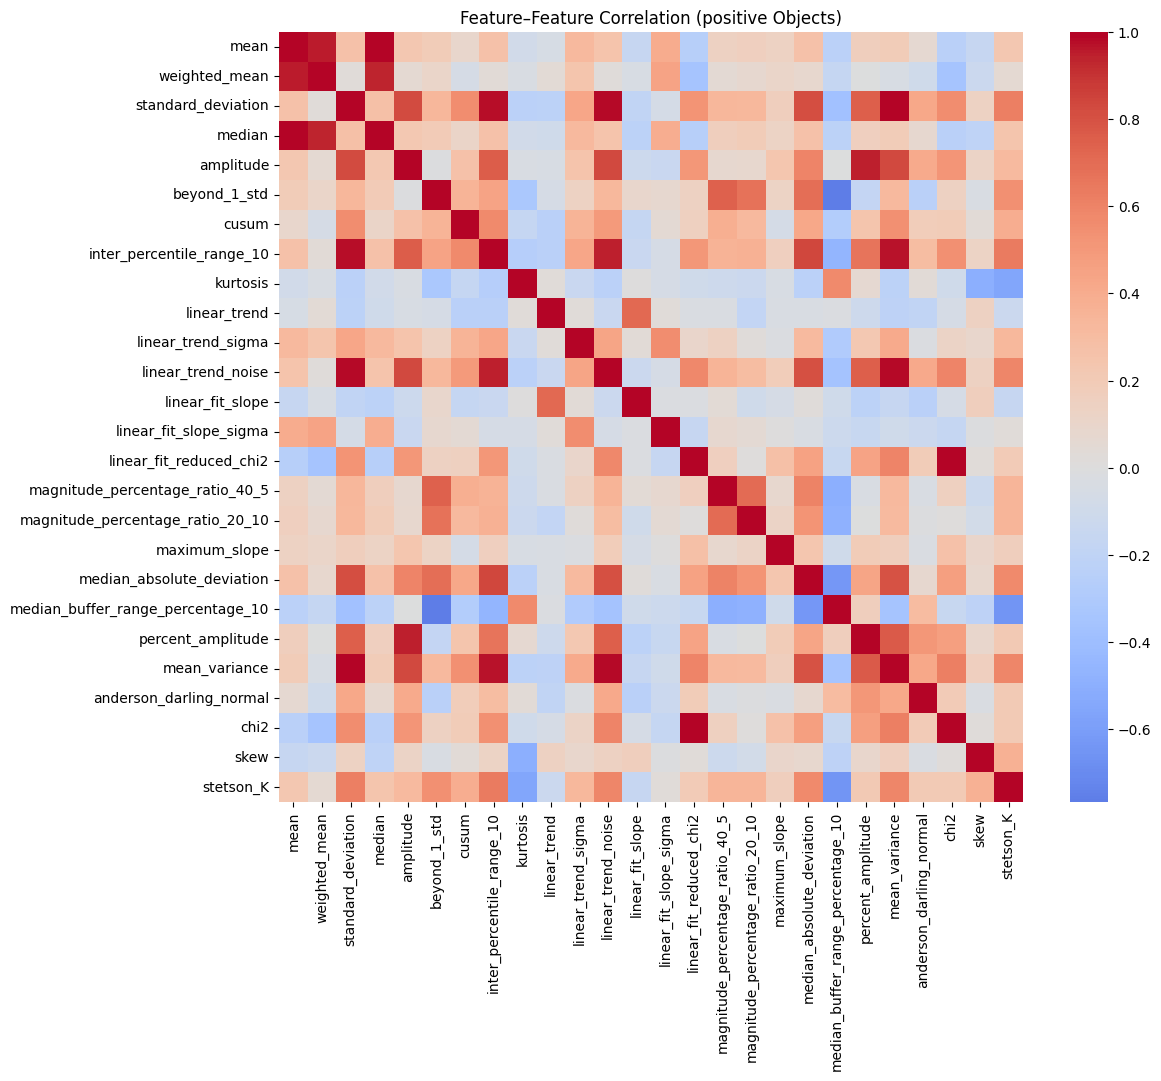

In [266]:
#heatmap plotting
plt.figure(figsize=(12, 10))
sns.heatmap(corr_pos, cmap='coolwarm', center=0)
plt.title('Feature–Feature Correlation (positive Objects)')
#plt.tight_layout()
plt.show()

In [267]:
# Load your parquet file
df_neg = pd.read_csv("negatives_lightcurves_grouped.parquet")

# Check shape and columns
print(df_neg.shape)
print(df_neg.columns)

(1471, 25)
Index(['object', 'oid', 'expid', 'hjd', 'mjd', 'mag', 'magerr', 'catflags',
       'filtercode', 'ra', 'dec', 'chi', 'sharp', 'filefracday', 'field',
       'ccdid', 'qid', 'limitmag', 'magzp', 'magzprms', 'clrcoeff', 'clrcounc',
       'exptime', 'airmass', 'programid'],
      dtype='object')


In [268]:
# Function to parse semicolon-separated arrays
def parse_array(x):
    return np.array([float(v) for v in str(x).split(";") if v != ""])
# Collect results
results = [] #empty array to store results
#Iterate through each row of the DataFrame (each row = one object) for negative objects
for _, row in df_neg.iterrows():
    try:
        t = parse_array(row["hjd"]) #time array for heleocentric julian date
        m = parse_array(row["mag"]) #magnitude column
        err = parse_array(row["magerr"]) #error
        feats = extractor(t, m, err, sorted=True, check=False)
        results.append([row["object"]] + list(feats))
    except Exception as e:
        print(f" Skipping {row['object']} due to error: {e}")

# Create DataFrame with proper headers
features_df_neg = pd.DataFrame(results, columns=["object"] + extractor.names)

# Save to CSV and Excel
features_df_neg.to_parquet("negative_lightcurve_features_26.parquet", index=False)
print(" negative_Feature extraction complete! Saved to:")
print("   - negative_lightcurve_features_26.parquet")
#shape
print(features_df_neg.shape)

 negative_Feature extraction complete! Saved to:
   - negative_lightcurve_features_26.parquet
(1471, 27)


In [269]:
# Assuming first column is object and dropping the non numeric entry
features_neg = features_df_neg.drop(columns=['object'])
#correlation matrix calculation
corr_neg = features_neg.corr()

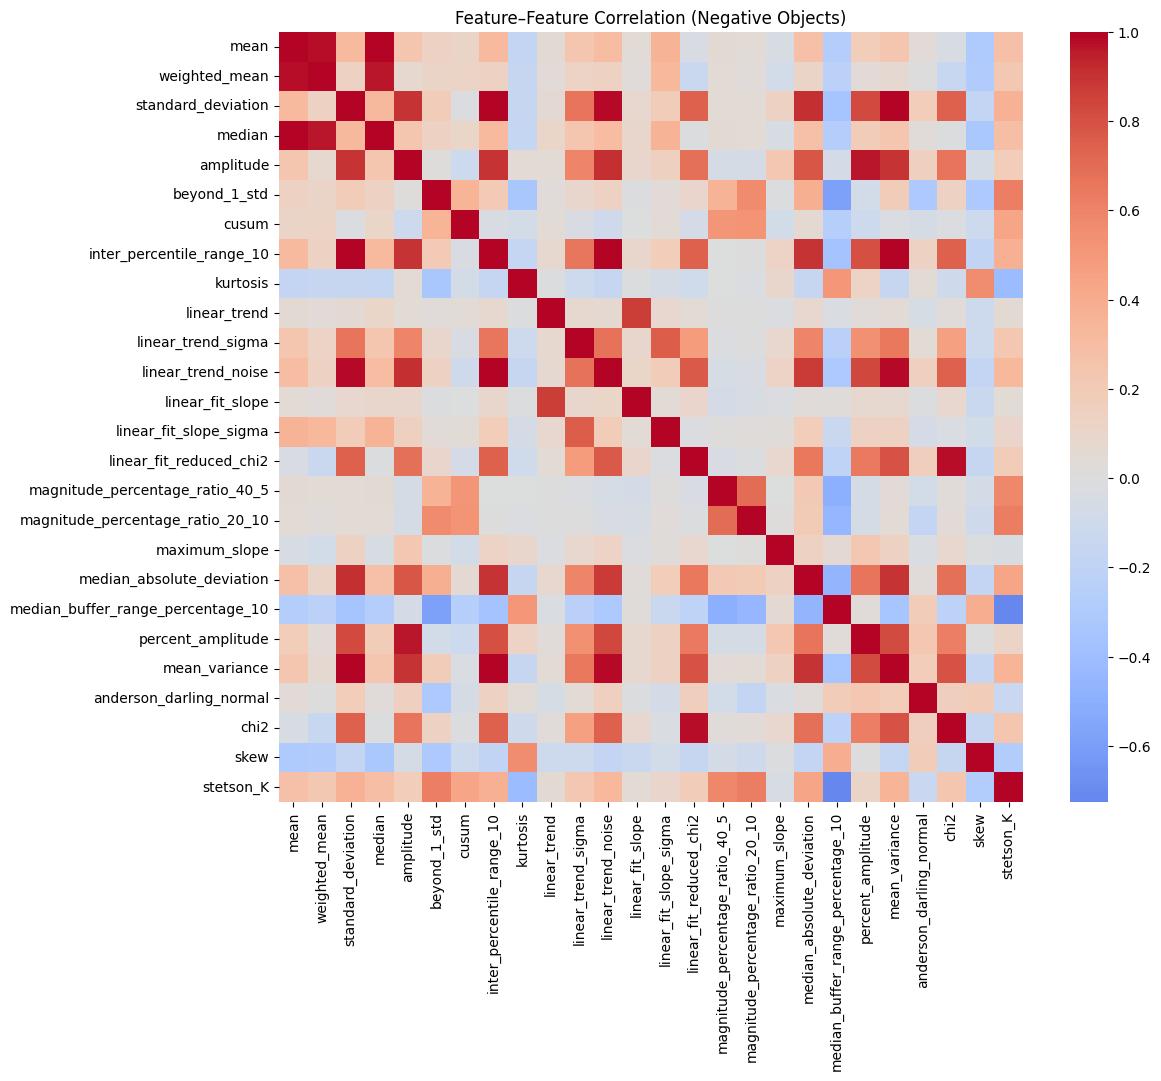

In [270]:
#plotting heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_neg, cmap='coolwarm', center=0)
plt.title('Feature–Feature Correlation (Negative Objects)')
#plt.tight_layout()
plt.show()

In [271]:
# corr_cv and corr_neg are correlation matrices
corr_diff = corr_pos - corr_neg

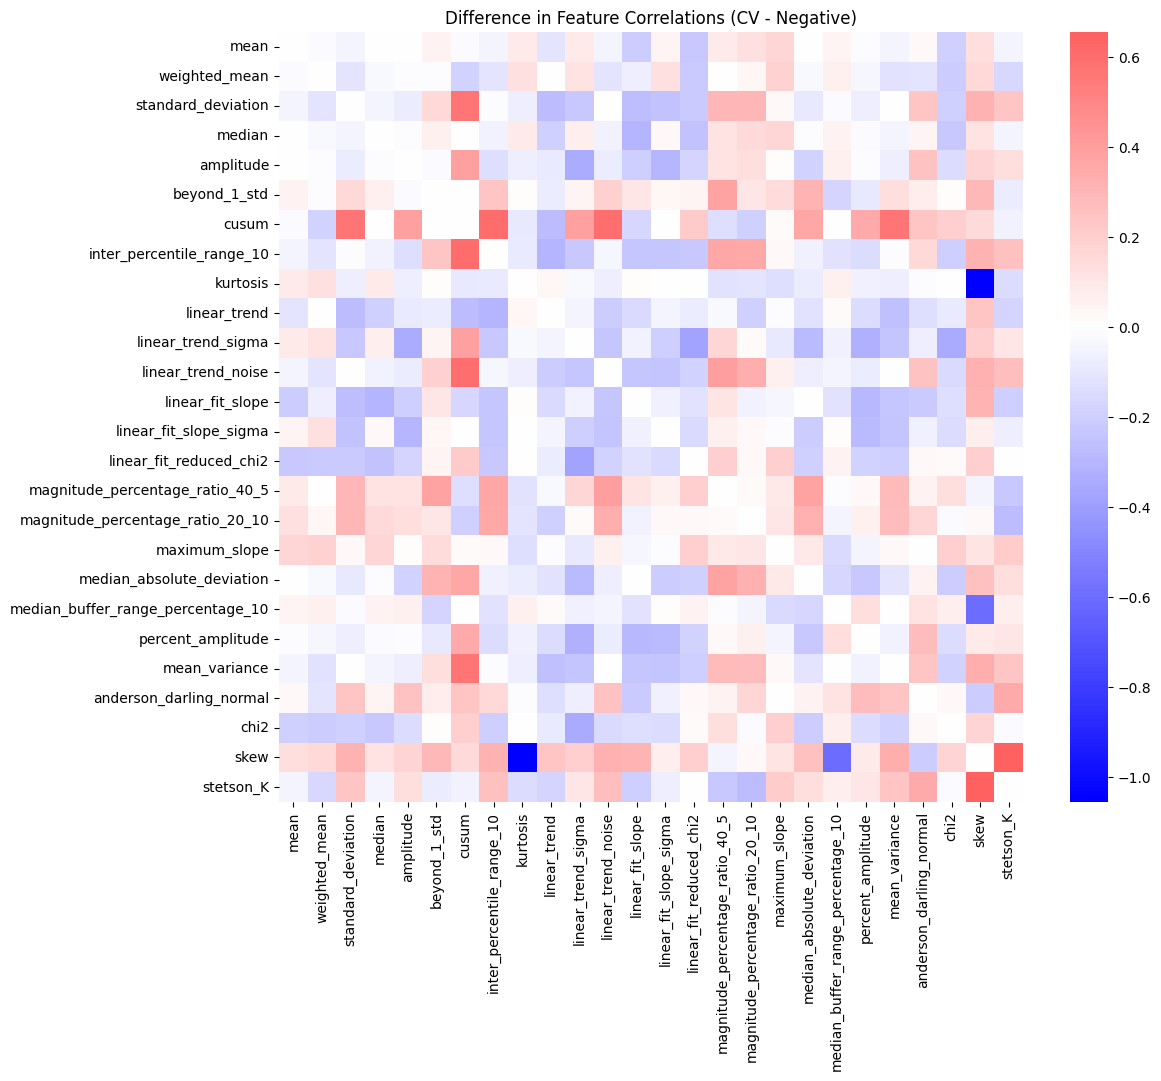

In [272]:
#difference between correlation f pos and neg
plt.figure(figsize=(12, 10))
sns.heatmap(corr_diff, cmap='bwr', center=0)
plt.title('Difference in Feature Correlations (CV - Negative)')
#plt.tight_layout()
plt.show()

In [273]:
#  Convert to long (pairwise) format
corr_diff_pairs = corr_diff.unstack()

#  Drop self-correlations (feature vs itself)
corr_diff_pairs = corr_diff_pairs[corr_diff_pairs.index.get_level_values(0) != corr_diff_pairs.index.get_level_values(1)]

#  Keep only one of (A,B) and (B,A) pairs to avoid duplication
corr_diff_pairs = corr_diff_pairs[ [i < j for i, j in corr_diff_pairs.index] ]

#  Sort by absolute difference
corr_diff_pairs = corr_diff_pairs.reindex(corr_diff_pairs.abs().sort_values(ascending=False).index)

#  Select feature pairs with large correlation difference
# e.g., absolute difference > 0.5, 0.5 because halfway diff is taken
high_corr_diff = corr_diff_pairs[abs(corr_diff_pairs) > 0.5]

print("Feature pairs with largest correlation difference between positive and negative sets:")
print(high_corr_diff)

Feature pairs with largest correlation difference between positive and negative sets:
kurtosis                           skew                        -1.055600
skew                               stetson_K                    0.655793
median_buffer_range_percentage_10  skew                        -0.603718
cusum                              inter_percentile_range_10    0.603159
                                   linear_trend_noise           0.589432
                                   mean_variance                0.572775
                                   standard_deviation           0.572118
dtype: float64


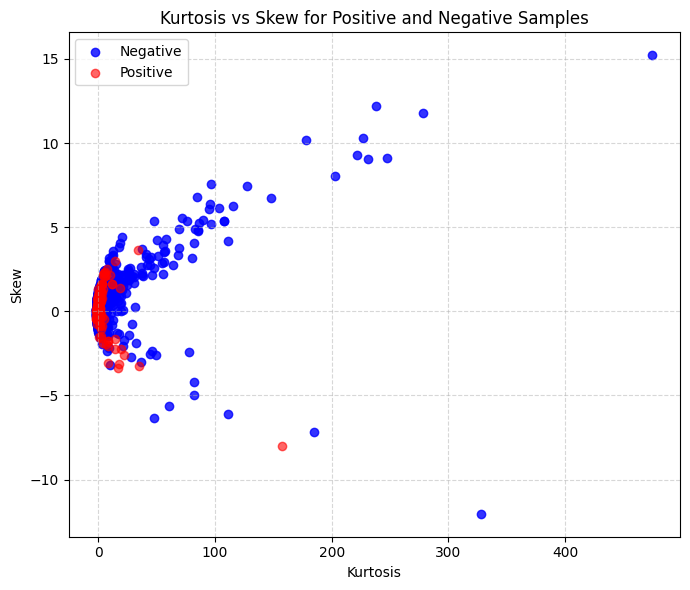

In [274]:
#skew and kurtosis
plt.figure(figsize=(7, 6))
# Plot negatives
plt.scatter(features_neg['kurtosis'], features_neg['skew'],
            color='blue', alpha=0.8, label='Negative')

# Plot positives
plt.scatter(features_pos['kurtosis'], features_pos['skew'],
            color='red', alpha=0.6, label='Positive')



plt.xlabel('Kurtosis')
plt.ylabel('Skew')
plt.title('Kurtosis vs Skew for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

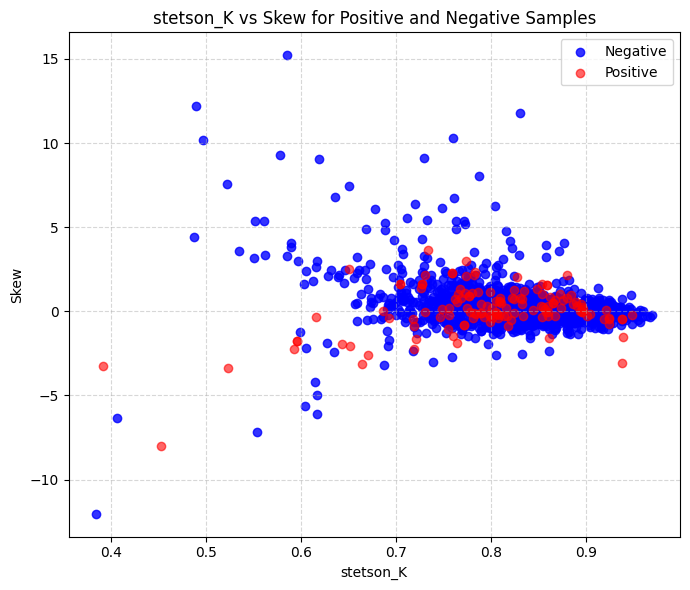

In [275]:
#skew and stetson_k

plt.figure(figsize=(7, 6))
# Plot negatives
plt.scatter(features_neg['stetson_K'], features_neg['skew'],
            color='blue', alpha=0.8, label='Negative')

# Plot positives
plt.scatter(features_pos['stetson_K'], features_pos['skew'],
            color='red', alpha=0.6, label='Positive')



plt.xlabel('stetson_K')
plt.ylabel('Skew')
plt.title('stetson_K vs Skew for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

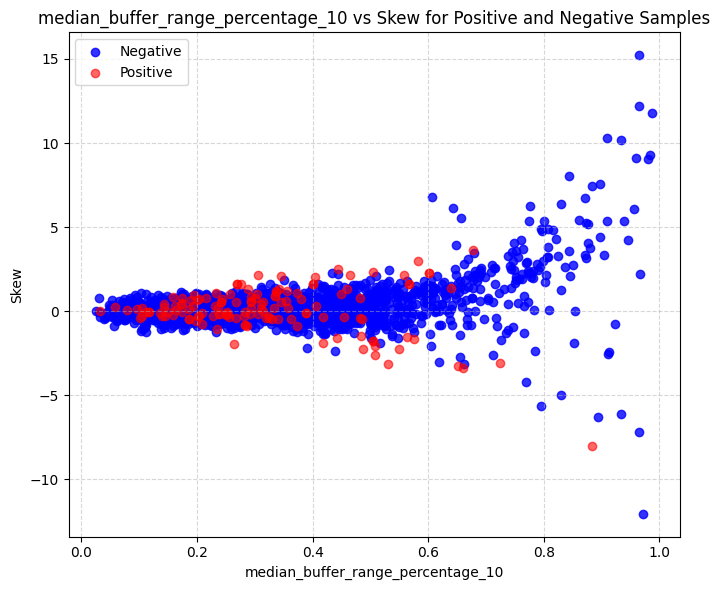

In [276]:
#median_buffer_range_percentage_10 and skew
plt.figure(figsize=(7, 6))
# Plot negatives
plt.scatter(features_neg['median_buffer_range_percentage_10'], features_neg['skew'],
            color='blue', alpha=0.8, label='Negative')
# Plot positives
plt.scatter(features_pos['median_buffer_range_percentage_10'], features_pos['skew'],
            color='red', alpha=0.6, label='Positive')



plt.xlabel('median_buffer_range_percentage_10')
plt.ylabel('Skew')
plt.title('median_buffer_range_percentage_10 vs Skew for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

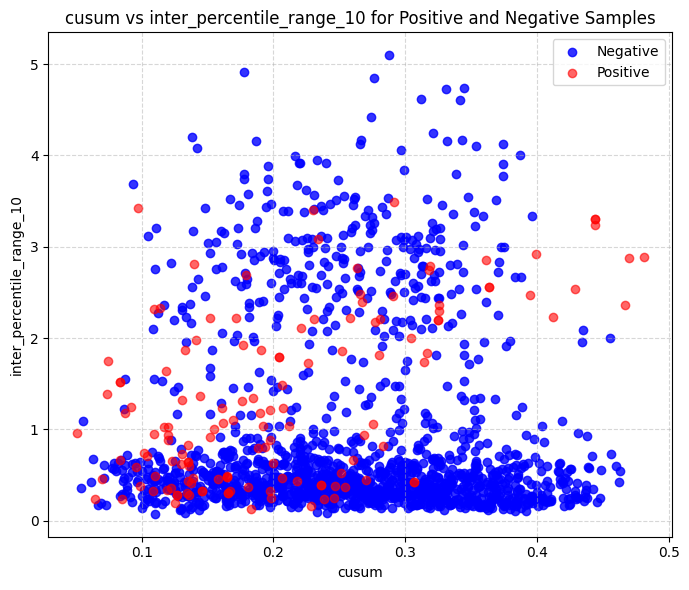

In [277]:
#cumulative sum & inter_percentile_range_10

plt.figure(figsize=(7, 6))
# Plot negatives
plt.scatter(features_neg['cusum'], features_neg['inter_percentile_range_10'],
            color='blue', alpha=0.8, label='Negative')
# Plot positives
plt.scatter(features_pos['cusum'], features_pos['inter_percentile_range_10'],
            color='red', alpha=0.6, label='Positive')



plt.xlabel('cusum')
plt.ylabel('inter_percentile_range_10')
plt.title('cusum vs inter_percentile_range_10 for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


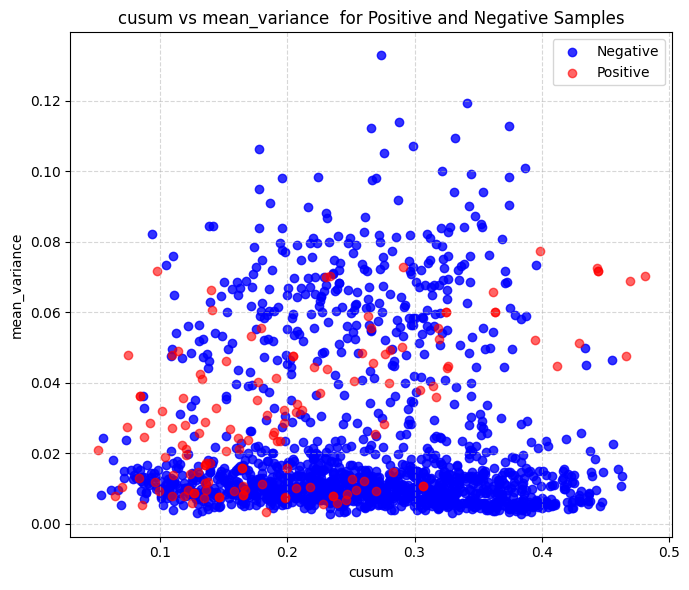

In [278]:
#cumulative sum and mean varience

plt.figure(figsize=(7, 6))

# Plot negatives
plt.scatter(features_neg['cusum'], features_neg['mean_variance'],
            color='blue', alpha=0.8, label='Negative')


# Plot positives
plt.scatter(features_pos['cusum'], features_pos['mean_variance'],
            color='red', alpha=0.6, label='Positive')


plt.xlabel('cusum')
plt.ylabel('mean_variance')
plt.title('cusum vs mean_variance  for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

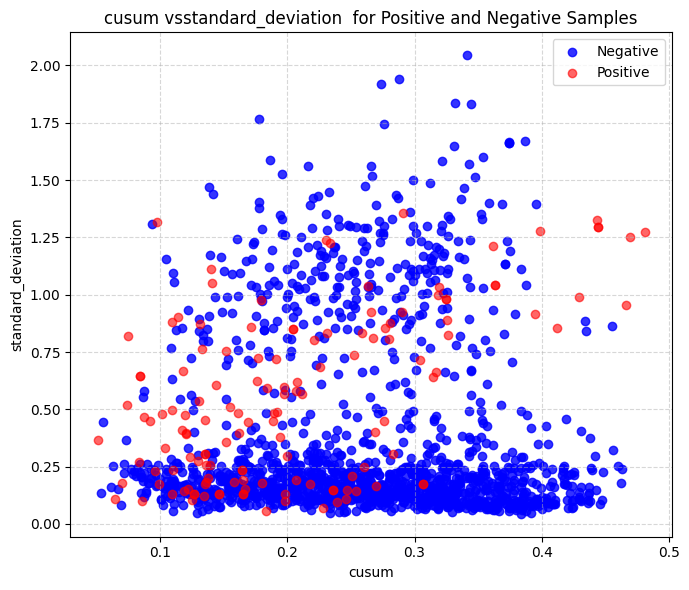

In [279]:
#cumulative sum & standard deviation
plt.figure(figsize=(7, 6))

# Plot negatives
plt.scatter(features_neg['cusum'], features_neg['standard_deviation'],
            color='blue', alpha=0.8, label='Negative')
# Plot positives
plt.scatter(features_pos['cusum'], features_pos['standard_deviation'],
            color='red', alpha=0.6, label='Positive')



plt.xlabel('cusum')
plt.ylabel('standard_deviation')
plt.title('cusum vsstandard_deviation  for Positive and Negative Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [280]:
# lightcurve feature dataset for Mcvs and non-Mcv(unknowns)
positives=pd.read_parquet('lightcurve_features_26.parquet')
negatives=pd.read_parquet('negative_lightcurve_features_26.parquet')

In [281]:
#combine them
combined = pd.concat([positives,negatives])
# Shuffle the combined dataset
combined = combined.sample(frac=1)#.reset_index(drop=True)
#save
combined.to_parquet("biggie_set_with_all_neg_and_pos.parquet", index=False)
#print shape
print("Combined and shuffled dataset saved")
print("Total rows:", len(combined))

Combined and shuffled dataset saved
Total rows: 1610


In [282]:
#load combined data
df=pd.read_parquet("biggie_set_with_all_neg_and_pos.parquet")

In [283]:
#keep numeic values only
#X
X = df.drop(columns=['object']).values

In [284]:
# object column contains names like 'ZTF18abc...' or non-ZTF names : Binary conversion of objects
y = np.where(df['object'].str.contains('ZTF', case=False),
             0,   # for my case ZTF=negative
              1)   # non-ZTF = positive

In [285]:
#varying random seeds in different run
SEED = 12#58 #42 #32 #24 #12
#varying train size and n estimator size to get best values
train_sizes = np.arange(0.5, 0.91, 0.1)   # train size
n_estimators = np.arange(50, 201, 20)      # number of trees

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=size,
        shuffle=True,
        random_state=SEED,
        # stratify=y
    )

    # Count classes in this train/test split
    train_positive = np.sum(y_train == 1)
    train_negative = np.sum(y_train == 0)

    test_positive = np.sum(y_test == 1)
    test_negative = np.sum(y_test == 0)

    for n in n_estimators:

        # XGBoost model
        model = XGBClassifier(
            n_estimators=n,
            max_depth=10, #keeping them fixed
            learning_rate=0.3,
            eval_metric='logloss',
            random_state=SEED
        )

        # Model fitting
        model.fit(X_train, y_train)

        # Prediction
        y_pred = model.predict(X_test)

        # Evaluation
        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=1)
        recall = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)

        # Store results
        results.append({
            "train_size": size,
            "n_estimators": n,
            "max_depth": 10,
            "learning_rate": 0.3,

            # Class counts
            "train_positive": train_positive,
            "train_negative": train_negative,
            "test_positive": test_positive,
            "test_negative": test_negative,

            # Performance
            "accuracy": acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

results_df = pd.DataFrame(results)

In [286]:
# Find best configuration based on precision
best_row = results_df.loc[results_df["precision"].idxmax()]

best_train_size = best_row["train_size"]
best_n_estimators = best_row["n_estimators"]
best_max_depth = best_row["max_depth"]
best_learning_rate = best_row["learning_rate"]

# Training and test class counts
best_train_positive = best_row["train_positive"]
best_train_negative = best_row["train_negative"]
best_test_positive = best_row["test_positive"]
best_test_negative = best_row["test_negative"]

# Performance metrics
best_accuracy = best_row["accuracy"]
best_precision = best_row["precision"]
best_recall = best_row["recall"]
best_f1 = best_row["f1_score"]

print("Best configuration based on precision:")
print(f"Train size        : {best_train_size}")
print(f"n_estimators      : {best_n_estimators}")
print(f"max_depth         : {best_max_depth}")
print(f"learning_rate     : {best_learning_rate}")

print("\nTraining set:")
print(f"CV (positive)     : {int(best_train_positive)}")
print(f"Unknown (negative): {int(best_train_negative)}")
print(f"Total             : {int(best_train_positive + best_train_negative)}")

print("\nTest set:")
print(f"CV (positive)     : {int(best_test_positive)}")
print(f"Unknown (negative): {int(best_test_negative)}")
print(f"Total             : {int(best_test_positive + best_test_negative)}")

print("\nTest performance:")
print(f"Accuracy           : {best_accuracy:.4f}")
print(f"Precision          : {best_precision:.4f}")
print(f"Recall             : {best_recall:.4f}")
print(f"F1-score           : {best_f1:.4f}")

# Save best configuration
best_row.to_frame().T.to_csv(
    "best_configuration_RS_12_1.csv",
    index=False
)

Best configuration based on precision:
Train size        : 0.5
n_estimators      : 110.0
max_depth         : 10.0
learning_rate     : 0.3

Training set:
CV (positive)     : 76
Unknown (negative): 729
Total             : 805

Test set:
CV (positive)     : 63
Unknown (negative): 742
Total             : 805

Test performance:
Accuracy           : 0.9615
Precision          : 0.8333
Recall             : 0.6349
F1-score           : 0.7207


In [287]:
#train the best model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=best_train_size,
    #stratify=y,
    random_state=12 #58#42 #32 #24#12
)
#best model with best parameters
best_model = XGBClassifier(
    n_estimators=int(best_n_estimators),
    max_depth=int(best_max_depth),
    learning_rate=float(best_learning_rate),
    eval_metric='logloss',
    n_jobs=-1
)
#fit best model
best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [288]:
#predict model
y_pred = best_model.predict(X_test)
#print(y_pred)
#accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
#precision
print("Precision:", precision_score(y_test, y_pred))
probs = best_model.predict_proba(X_test)
#print('probs',probs)

Accuracy: 0.9614906832298137
Precision: 0.8333333333333334


Confusion matrix (raw counts):
[[734   8]
 [ 23  40]]


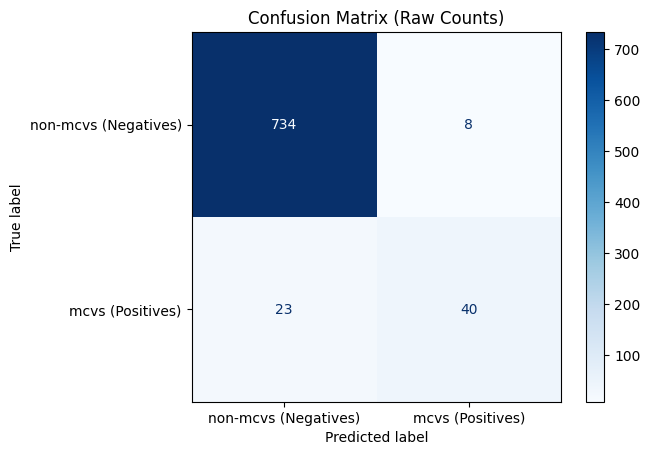

In [289]:
# For best model CONFUSION MATRIX + TP / TN / FP / FN IDENTIFICATION
# Class labels for clarity
class_names = ["non-mcvs (Negatives)", "mcvs (Positives)"]

# Plot confusion matrix (raw counts)
disp = ConfusionMatrixDisplay.from_estimator(
   best_model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap=plt.cm.Blues #heatmap
)

disp.ax_.set_title("Confusion Matrix (Raw Counts)")
print("Confusion matrix (raw counts):")
print(disp.confusion_matrix)

plt.show()


# Extract TN, FP, FN, TP explicitly
# Label convention used in  code:
#   0 :ZTF names (negative, non-CV)
#   +1 :non-ZTF names (positive, CV)

cm = confusion_matrix(y_test, best_model.predict(X_test), labels=[0, 1])

TN, FP, FN, TP = cm.ravel()

In [290]:
#saving the best model
joblib.dump(best_model, "cv_classifier_best_model_12_1.pkl")

['cv_classifier_best_model_12_1.pkl']

In [291]:
#analysing data as per  multiple random seeds
#list
random_seeds = [12,24,32,42,58,12_1]
precision=[0.907407407,0.9230769230,0.914893617,0.86,0.956521739,0.907407407]
training_size = [0.6, 0.9, 0.7, 0.5, 0.8, 0.6]
pre_percent=[pre* 100 for pre in precision] 

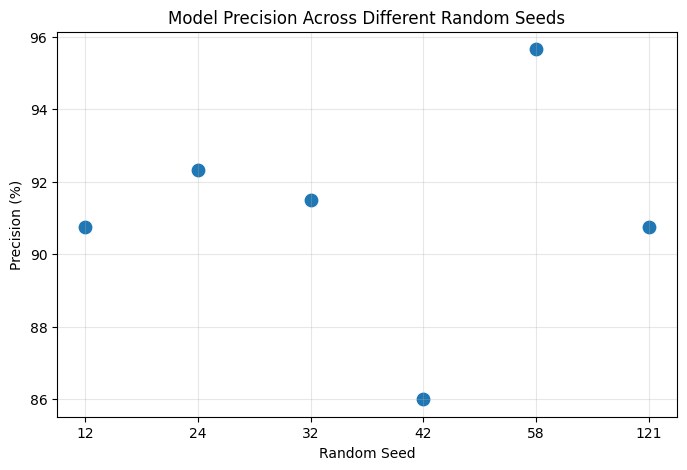

In [292]:
#plot outputs Model Precision Across Different Random Seeds
plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), pre_percent, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("Precision (%)")
plt.title("Model Precision Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

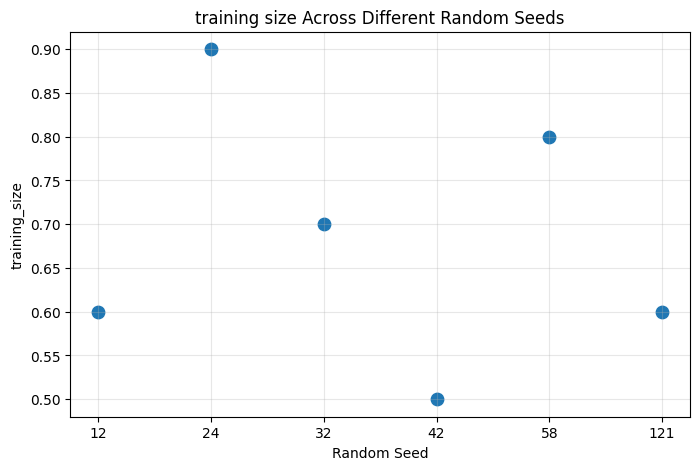

In [293]:
#Plot output training size Different Random Seeds
plt.figure(figsize=(8, 5))

plt.scatter(range(len(random_seeds)), training_size, s=80)

plt.xticks(range(len(random_seeds)), random_seeds)
plt.xlabel("Random Seed")
plt.ylabel("training_size")
plt.title("training size Across Different Random Seeds")

plt.grid(True, alpha=0.3)
plt.show()

In [294]:
#work with fetched data from fink
#load main dataset
df=pd.read_parquet('new_masked_object.parquet')

In [295]:
#make two different arrays for histogram part
cv_df = df[df["finkclass"].str.contains("CataclyV*")]
unknown_df = df[df["finkclass"] == "Unknown"]

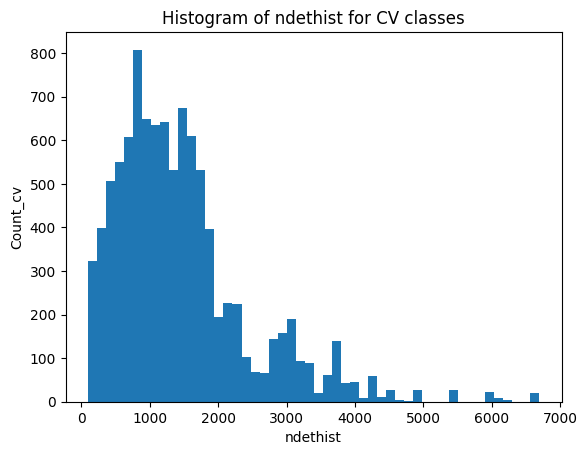

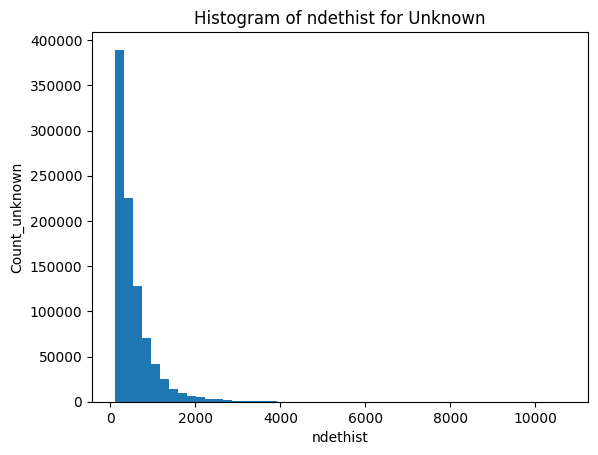

In [296]:
# CV classes histogram
#ndethist stands for number of observations points
#these are for checking the spread of datapoints for both cv and unknown
plt.hist(cv_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for CV classes")
plt.xlabel("ndethist")
plt.ylabel("Count_cv")
plt.show()

# Unknown histogram
plt.hist(unknown_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for Unknown")
plt.xlabel("ndethist")
plt.ylabel("Count_unknown")
plt.show()

In [297]:
#count of element distribution
print(df['finkclass'].value_counts())
print("Total objects:", len(df))

finkclass
Unknown                 926983
CataclyV*                 9894
CataclyV*_Candidate         49
Blazar                       0
WhiteDwarf_Candidate         0
Name: count, dtype: int64
Total objects: 936926


In [298]:
#data grouping via objectId for having a dataframe
data = df.groupby("objectId", as_index=False).agg(list)
#shape
data.shape
#count of element distribution wrt finkclass
print(data['finkclass'].value_counts())
print("Total objects:", len(data))

finkclass
[Unknown]                                                                                                                                                                                                                                                        127690
[Unknown, Unknown]                                                                                                                                                                                                                                                41826
[Unknown, Unknown, Unknown]                                                                                                                                                                                                                                       22134
[Unknown, Unknown, Unknown, Unknown]                                                                                                                                                                  

In [299]:
#check all unknown elements
unknown_df = data[data["finkclass"].apply(lambda x: all(v == "Unknown" for v in x))]
#count unknown objects
print("Pure Unknown objects:", len(unknown_df))
#check inputs with all cataclysemic variable data
cv_all = data[data["finkclass"].apply(lambda x: all(v in ["CataclyV*"] for v in x))]
#count cvs
print("CVs:", len(cv_all))

Pure Unknown objects: 262400
CVs: 984


In [300]:
#file making
unknown_sample = unknown_df.sample(n=1200, random_state=42)
# concatenation
final_df = pd.concat([unknown_sample, cv_all])
#shuffle 
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)
#final heads
#print(final_df.head())
print("Total objects:", len(final_df))

Total objects: 2184


In [301]:
#check if any repeated entries are here
print("Rows:", len(final_df))
print("Unique objects:", final_df["objectId"].nunique())
#saving final working dataset
final_df.to_parquet("my_dataset.parquet", index=False)

Rows: 2184
Unique objects: 2184


In [302]:
#print unique
#lightcurve extraction
# Load dataset (only first 5 rows for testing)
df_test = pd.read_parquet("my_dataset.parquet").head(5)
print("Total rows:", len(df_test))
# Group by objectId
#df_test = df_test0.groupby("objectId", as_index=False).agg(list)
#print ('total number of rows',len(df_test),'\n\n')
#groups = df_test.groupby("objectId")
#null array
all_rows = []
#r_count = 0   # counter for r-band detections
## Process objects
#i for count
for i in range(len(df_test)):
    object_id = df_test["objectId"].iloc[i]  #tracking objectIds
    print(f"Processing {i+1}: {object_id}")
#taking mean ra,dec to take all of them with the 1.2 arcsec circle
    ra = np.mean(df_test["ra"].iloc[i])
    dec = np.mean(df_test["dec"].iloc[i])
#finkclass as first entry,not in array form
    finkclass = df_test["finkclass"].iloc[i][0]
    try:
        # Query SNAD
        
        url = "https://db.ztf.snad.space/api/v3/data/latest/circle/full/json"   #web

        params = {
            "ra": ra,
            "dec": dec,
            "radius_arcsec": 1.2   #small circle
        }

        r = requests.get(url, params=params)
        r.raise_for_status()

        data = r.json()

        if len(data) == 0:         #if no data returned
            print("no data found..")
            continue
             # Extract light curve
       
        for name in data:     #loop over objects

            lc = data[name].get("lc", []) #"lc" key,a list of data points for the current name, defaulting to an empty list [] if it doesn't exis
            filt = data[name].get("meta", {}).get("filter", None) #navigates nested "meta" dictionary to retrieve the "filter" value, defaulting to None if meta or filter is missing.

            for point in lc: #loop over biggie lightcurve entries

                all_rows.append({       #adding inputs over objectids
                    "objectId": object_id,
                    "finkclass": finkclass,
                    "oid": name,
                    "mjd": point.get("mjd"),
                    "mag": point.get("mag"),
                    "magerr": point.get("magerr"),
                    "filter": filt
                })

    except Exception as e:
        print("Error fetching", object_id, e)  

    time.sleep(0.5)
    # Create dataframe

final_df = pd.DataFrame(all_rows)

print("Total photometry rows collected:", len(final_df))


# group
grouped_df = final_df.groupby("objectId").agg({   #grouping them
    "finkclass": "first",
    "oid": "first",
    "filter": list,
    "mjd": list,
    "mag": list,
    "magerr": list
}).reset_index()

print("Objects after grouping:", len(grouped_df))

# Save output

grouped_df.to_parquet("snad_lightcurves_grouped_2.parquet")

print("Saved file: snad_lightcurves_grouped_1.parquet")

# Display result


print(grouped_df.head())

Total rows: 5
Processing 1: ZTF19adbqerg
Processing 2: ZTF18aadggvs
Processing 3: ZTF20aceobuz
Processing 4: ZTF18abcpvwv
Error fetching ZTF18abcpvwv ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
Processing 5: ZTF19aapgrjj
Total photometry rows collected: 3877
Objects after grouping: 4
Saved file: snad_lightcurves_grouped_1.parquet
       objectId finkclass              oid  \
0  ZTF18aadggvs   Unknown  660101400014853   
1  ZTF19aapgrjj   Unknown  377306100002112   
2  ZTF19adbqerg   Unknown  779111400012846   
3  ZTF20aceobuz   Unknown  569108400002074   

                                              filter  \
0  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
1  [zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, zi, z...   
2  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   
3  [zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, zg, z...   

                                                 mjd  \
0  [582

In [303]:
#outside of this notebook I ran code to fetch lightcurves for my 2185 objects in "my_dataset.parquet" file
#output given as:Total photometry rows collected: 2948750
#Objects after grouping: 2092
#Saved file: snad_lightcurves_grouped.parquet
#loading the new file
df_new=pd.read_parquet("snad_lightcurves_grouped.parquet")

In [304]:
#loping over rband detections only
#introducing null array
mjd_r = []
mag_r = []
magerr_r = []
filter_r = []
#count objects
for i in range(len(df_new)):
    #putting mask of 'zr'
    mask = np.array(df_new.iloc[i]["filter"]) == "zr"
    #putting mask over lc data
    mjd = np.array(df_new.iloc[i]["mjd"])[mask]
    mag = np.array(df_new.iloc[i]["mag"])[mask]
    magerr = np.array(df_new.iloc[i]["magerr"])[mask]
    filt = np.array(df_new.iloc[i]["filter"])[mask]
    #saving them
    mjd_r.append(mjd)
    mag_r.append(mag)
    magerr_r.append(magerr)
    filter_r.append(filt)
#adding column to my files
df_new["mjd_r"] = mjd_r
df_new["mag_r"] = mag_r
df_new["magerr_r"] = magerr_r
df_new["filter_r"]=filter_r
#creating big lightcuve data
df_new.to_parquet("snad_lightcurves_grouped_r_band.parquet")

In [305]:
#extracting the statistical features from lightcurve info
results = []

for _, row in df_new.iterrows():

    try:
        t = np.array(row["mjd_r"])
        m = np.array(row["mag_r"])
        err = np.array(row["magerr_r"])

        feats = extractor(
            t, m, err,
            sorted=True,
            check=False
        )

        # If extractor returns a dictionary
        if isinstance(feats, dict):
            feature_values = [feats[name] for name in extractor.names]
        else:
            feature_values = list(feats)

        results.append(
            [row["objectId"], row["finkclass"]] + feature_values
        )

    except Exception as e:
        print(
            f"Skipping {row['objectId']} due to error: {e}"
        )
# Create dataframe
features_df = pd.DataFrame(
    results,
    columns=["objectId", "finkclass"] + list(extractor.names)
)
# Save feature space
features_df.to_parquet(
    "my_feature_space.parquet",
    index=False
)
print("Feature extraction complete!")
print("Keys", features_df.keys)
print("Shape:", features_df.shape)

Skipping ZTF17aaannua due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF17aaaojvc due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18aabfgwe due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18aabgvwv due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abahibj due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abgtzzh due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abjiitj due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abjpdyc due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abktleu due to error: time-series' length 0 is smaller than the minimum required length 1
Skipping ZTF18abmsmez due to error: time-series' length 0 is sma

In [306]:
#count of element distribution wrt finkclass
print(features_df['finkclass'].value_counts())
#print("Total objects:", len(data))

finkclass
Unknown                1081
CataclyV*               975
CataclyV*_Candidate       3
Name: count, dtype: int64


In [307]:
#load new fink data
df = pd.read_parquet("my_feature_space.parquet")

In [308]:
#load all models
model_12=joblib.load("cv_classifier_best_model_12.pkl")
model_24=joblib.load("cv_classifier_best_model_24.pkl")
model_32=joblib.load("cv_classifier_best_model_32.pkl")
model_42=joblib.load("cv_classifier_best_model_42.pkl")
model_58=joblib.load("cv_classifier_best_model_58.pkl")
model_12_1=joblib.load("cv_classifier_best_model_12_1.pkl")

In [309]:
#feature space
feature_columns = df.drop(columns=['objectId', 'finkclass']).columns #drop non_numeric columns
#features
X = df[feature_columns].values #feature column
#predict model
y_pred_12 = model.predict(X) 
y_pred_24 = model.predict(X)
y_pred_32 = model.predict(X)
y_pred_42 = model.predict(X)
y_pred_58 = model.predict(X)
y_pred_12_1 = model.predict(X)
#print("Unique predictions:", np.unique(y_pred_12)) #cross check

In [310]:
# Check class probabilities for the test set.
# predict_proba returns an array of shape (N_test, 2),
# where N_test is the number of test objects.
# Column 0 : probability of class 0 (negative, unknown)
# Column 1 : probability of class +1 (positive, cvs)
probs_12 = model_12.predict_proba(X)
probs_24 = model_24.predict_proba(X)
probs_32 = model_32.predict_proba(X)
probs_42 = model_42.predict_proba(X)
probs_58 = model_58.predict_proba(X)
probs_12_1 = model_12_1.predict_proba(X)




#print('probs',probs)

In [311]:
# CV probability with finkclass_column_atached
cv_prob_12 = probs_12[:,1]
cv_prob_24 = probs_24[:,1]
cv_prob_32 = probs_32[:,1]
cv_prob_42 = probs_42[:,1]
cv_prob_58 = probs_58[:,1]
cv_prob_12_1 = probs_12_1[:,1]

# create dataframe with required columns
prob_df_12= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_12
})
prob_df_24= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_24
})
prob_df_32= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_32
})
prob_df_42= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_42
})
prob_df_58= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_58
})
prob_df_12_1= pd.DataFrame({
    "objectId": df["objectId"],
    "finkclass": df["finkclass"],
    "cv_probability": cv_prob_12_1
})


In [312]:
#saving them
prob_df_12.to_csv("class_prediction_RS_12.csv", index=False)
prob_df_24.to_csv("class_prediction_RS_24.csv", index=False)
prob_df_32.to_csv("class_prediction_RS_32.csv", index=False)
prob_df_42.to_csv("class_prediction_RS_42.csv", index=False)
prob_df_58.to_csv("class_prediction_RS_58.csv", index=False)
prob_df_12_1.to_csv("class_prediction_RS_12_1.csv", index=False)

In [313]:
#probablity distribution checking
high_prob_12 = prob_df_12[prob_df_12["cv_probability"] > 0.9]
high_prob_24 = prob_df_24[prob_df_24["cv_probability"] > 0.9]
high_prob_32 = prob_df_32[prob_df_32["cv_probability"] > 0.9]
high_prob_42 = prob_df_42[prob_df_42["cv_probability"] > 0.9]
high_prob_58 = prob_df_58[prob_df_58["cv_probability"] > 0.9]
high_prob_12_1 = prob_df_12_1[prob_df_12_1["cv_probability"] > 0.9]

In [314]:
#saving into parquet
high_prob_12.to_csv("predicted_cv_candidates_above_0.9_RS_12.csv", index=False)
high_prob_24.to_csv("predicted_cv_candidates_above_0.9_RS_24.csv", index=False)
high_prob_32.to_csv("predicted_cv_candidates_above_0.9_RS_32.csv", index=False)
high_prob_42.to_csv("predicted_cv_candidates_above_0.9_RS_42.csv", index=False)
high_prob_58.to_csv("predicted_cv_candidates_above_0.9_RS_58.csv", index=False)
high_prob_12_1.to_csv("predicted_cv_candidates_above_0.9_RS_12_1.csv", index=False)

In [315]:
# output files for all models
files = {
    "RS_12": "predicted_cv_candidates_above_0.9_RS_12.csv",
    "RS_24": "predicted_cv_candidates_above_0.9_RS_24.csv",
    "RS_32": "predicted_cv_candidates_above_0.9_RS_32.csv",
    "RS_42": "predicted_cv_candidates_above_0.9_RS_42.csv",
    "RS_58": "predicted_cv_candidates_above_0.9_RS_58.csv",
    "RS_12_1": "predicted_cv_candidates_above_0.9_RS_12_1.csv"
}


# Keep finkclass from RS_12 as finkclass is same of the objects
finkclass_df = pd.read_csv(
    files["RS_12"],
    usecols=["objectId", "finkclass"]
)

# Read each CSV
dfs = {}

for name, file in files.items():

    df = pd.read_csv(file)

    # Keep objectId and CV probability
    df = df[["objectId", "cv_probability"]].copy()

    # Rename probability column
    df = df.rename(columns={
        "cv_probability": f"CV_probability_{name}"
    })

    dfs[name] = df


# Merge all files using OUTER JOIN
merged_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="objectId",
        how="outer"
    ),
    dfs.values()
)


# Add finkclass
merged_df = pd.merge(
    merged_df,
    finkclass_df,
    on="objectId",
    how="left"
)


# Find probability columns
probability_columns = [
    col for col in merged_df.columns
    if col.startswith("CV_probability_")
]


# Count how many files contain each object
merged_df["number_of_files"] = (
    merged_df[probability_columns]
    .notna()
    .sum(axis=1)
)


# Create a column showing which files contain each object
def find_common_files(row):

    common_files = []

    for name in files.keys():

        column = f"CV_probability_{name}"

        if pd.notna(row[column]):
            common_files.append(name)

    return ", ".join(common_files)


merged_df["common_in_files"] = merged_df.apply(
    find_common_files,
    axis=1
)
# Keep ONLY objects present in ALL 6 files
common_objects_all_6 = merged_df[
    merged_df["number_of_files"] == 6
].copy()


# Sort by objectId
common_objects_all_6 = common_objects_all_6.sort_values(
    by="objectId"
)


# Save the result
common_objects_all_6.to_csv(
    "common_MCV_candidates_across_all_random_seeds.csv",
    index=False
)


# Print result
print(
    f"Total objects common to all 6 files: "
    f"{len(common_objects_all_6)}"
)


print(
    common_objects_all_6[
        [
            "objectId",
            "finkclass",
            "CV_probability_RS_12",
            "CV_probability_RS_24",
            "CV_probability_RS_32",
            "CV_probability_RS_42",
            "CV_probability_RS_58",
            "CV_probability_RS_12_1"
        ]
    ].head(20)
)

Total objects common to all 6 files: 300
        objectId  finkclass  CV_probability_RS_12  CV_probability_RS_24  \
0   ZTF17aaaadkj  CataclyV*              0.997399              0.996593   
1   ZTF17aaaagyq  CataclyV*              0.929628              0.950510   
2   ZTF17aaaazob  CataclyV*              0.904065              0.962300   
3   ZTF17aaabavb  CataclyV*              0.997190              0.992844   
9   ZTF17aaadasj  CataclyV*              0.995787              0.998499   
11  ZTF17aaaehqt  CataclyV*              0.982294              0.952287   
12  ZTF17aaaeslm  CataclyV*              0.998758              0.997265   
14  ZTF17aaafglk  CataclyV*              0.954604              0.985656   
19  ZTF17aaagywy  CataclyV*              0.997794              0.998465   
31  ZTF17aaaiwfl  CataclyV*              0.993930              0.995533   
32  ZTF17aaaizeq  CataclyV*              0.998667              0.996352   
33  ZTF17aaaizfe  CataclyV*              0.999589          